# 05 - Take-off and landing

References: Roskam & Lan, Chapter 10; Anderson, Secs. 6.6-6.8.

In [1]:
# --- Setup -------------------------------------------------------------------
# The notebooks live in PrestazioniRoskam/, one level below the repository root,
# where the `aircraft_performance` package is. Make it importable:
import sys
import pathlib
ROOT = pathlib.Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

import aircraft_performance as ap
from aircraft_performance import units as u
from aircraft_performance.atmosphere import isa
from aircraft_performance.plotting import apply_style, reference_line
from aircraft_performance.reporting import print_table

apply_style()
print(f"aircraft_performance v{ap.__version__} ready")

from aircraft_performance import takeoff_landing as tl, climb, aerodynamics as aero
from aircraft_performance.aerodynamics import ParabolicDragPolar

single = ap.examples.light_single_piston()
twin = ap.examples.roskam_light_twin()
atr = ap.examples.regional_turboprop()
jet = ap.examples.business_jet_giv()
fleet = (single, twin, atr, jet)

aircraft_performance v1.0.0 ready


## 1. The take-off: phases, speeds, regulations

The take-off distance (Roskam Fig. 10.6, Eqn 10.1) is the sum of

$$
S_{TO} = \underbrace{S_{NGR} + S_R}_{\text{ground distance } S_G} + \underbrace{S_{TR} + S_{CL}}_{\text{air distance } S_A}
$$

* $S_{NGR}$: ground roll with the nose wheel on the ground, $0\to V_R$;
* $S_R$: rotation, $V_R \to V_{LOF}$ (1 s light aircraft, 2 s fighters, 3 s transports);
* $S_{TR}$: transition, a circular arc from lift-off to a straight climb;
* $S_{CL}$: straight climb to the **screen height**: 35 ft for FAR 25, 50 ft for
  FAR 23 and military aircraft.

Reference speeds (Roskam Table 10.1): typical preliminary values are
$V_R\approx1.10V_S$, $V_{LOF}\approx1.15V_S$ (FAR 25: $V_{LOF}\ge1.10V_{MU}$),
$V_2\ge1.2V_S$ at the screen. For multi-engine transports the take-off field
length is the **balanced field length**, where the accelerate-stop and
accelerate-go distances after an engine failure at $V_1$ are equal (Figs. 10.3-10.5).

In [2]:
print_table(["screen height", "[ft]", "[m]"], [[k, v / u.FT, v] for k, v in tl.SCREEN_HEIGHT.items()],
            ["{}", "{:.0f}", "{:.2f}"])
print()
print_table(["runway surface", "rolling friction mu"], list(tl.ROLLING_FRICTION.items()), ["{}", "{:.3f}"])
print()
print_table(["runway surface", "braking mu min", "max"], [[k, *v] for k, v in tl.BRAKING_FRICTION.items()],
            ["{}", "{:.2f}", "{:.2f}"])

   screen height  [ft]    [m]
----------------  ----  -----
   FAR25_takeoff    35  10.67
   FAR23_takeoff    50  15.24
military_takeoff    50  15.24
         landing    50  15.24

    runway surface  rolling friction mu
------------------  -------------------
concrete / asphalt                0.025
         hard turf                0.050
       short grass                0.050
        long grass                0.100
       soft ground                0.200

        runway surface  braking mu min   max
----------------------  --------------  ----
dry concrete / asphalt            0.65  0.80
wet concrete / asphalt            0.25  0.75
                 slush            0.15  0.40
 dry ice / packed snow            0.05  0.05


## 2. Equation of motion on the runway and ground effect

With the lift $L_g$ and drag $D_g$ computed **in ground effect**, the rolling
friction $\mu$ acting on $W - L_g$ and a runway slope $\phi$ (Roskam Eqns 10.4-10.5):

$$
\frac{dV}{dt} = a_g = g\left[\left(\frac{T}{W}-\mu\right) - \frac{(C_{D_g}-\mu C_{L_g})\,q}{W/S} - \phi\right]
$$

and the ground distance is $S_G=\int (V \mp V_w)/a_g\,dV$ (Eqn 10.8).

**Ground effect** reduces the induced drag: $\Delta C_{D_i} = -(1-\sigma')\,C_L^2/(\pi A)$
(Eqn 10.12) with (Eqn 10.13, valid for $0.033\le h/b\le0.25$)

$$
\sigma' = \frac{1 - 1.32\,h/b}{1.05 + 7.4\,h/b}
$$

where $h$ is the height of the wing above the ground: $h/b\approx0.1$ for low
wings, $0.2$ for high wings. The ground-run lift coefficient that minimises
$C_{D_g}-\mu C_{L_g}$ is $C_{L_g}=\mu/(2K)$ (Roskam Problem 10.4).

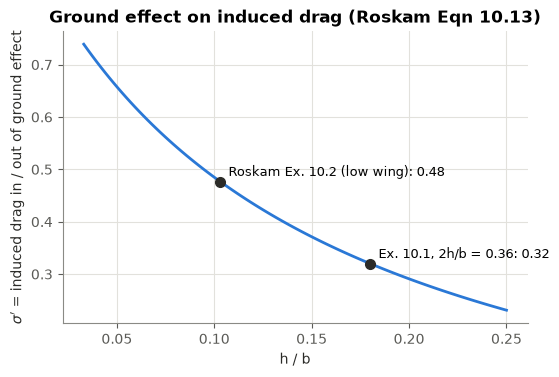

In [3]:
hb = np.linspace(0.033, 0.25, 100)
fig, ax = plt.subplots(figsize=(6, 3.8))
ax.plot(hb, aero.ground_effect_factor(hb))
for label, x in (("Roskam Ex. 10.2 (low wing)", 0.103), ("Ex. 10.1, 2h/b = 0.36", 0.18)):
    ax.plot(x, aero.ground_effect_factor(x), "o", color="#2b2b28")
    ax.annotate(f"{label}: {aero.ground_effect_factor(x):.2f}", (x, aero.ground_effect_factor(x)),
                xytext=(6, 4), textcoords="offset points", fontsize=9)
ax.set_xlabel("h / b"); ax.set_ylabel("$\\sigma'$ = induced drag in / out of ground effect")
ax.set_title("Ground effect on induced drag (Roskam Eqn 10.13)")
plt.show()

## 3. Roskam's approximate analytical method (Sec. 10.3.3, Example 10.2)

* **Ground roll to $V_R$**: $a_g$ is assumed linear in $V^2$ between $a_0=a_g(0)$
  and $a_R=a_g(V_R)$, then (Eqns 10.29-10.30)

  $$S_{NGR} = \frac{V_R^2}{2\,k\,a_0},\qquad k = \frac{1-a_R/a_0}{\ln(a_0/a_R)}$$

* **Rotation**: $S_R = \tfrac12(V_R+V_{LOF})\,t_{rotate}$ (Eqn 10.37);
* **Transition** on a circle of radius $R_{TR} = 2(W/S)/(\rho g\,\Delta C_L)$
  with the "normal effort" lift increment of Eqn (10.42), up to the climb angle
  $\sin\theta = (T-D)/W$ at $V_{LOF}$: $S_{TR} = R_{TR}\sin\theta$, $h_{TR}=R_{TR}(1-\cos\theta)$;
* **Climb to the screen**: $S_{CL} = (h_{screen}-h_{TR})/\tan\theta$.

Roskam Example 10.2: twin, $W=4{,}600$ lb, $S=175$ ft$^2$, $A=7$, $e=0.8$,
$C_{D_0,TO}=0.062$, $C_{L_{max,TO}}=1.69$, $\mu=0.03$, $C_{L_g}=0.89$,
$C_{D_g}=0.0862$, thrust decreasing linearly from 2,000 lb (static) to 1,200 lb
at $V_R$ (Fig. 10.9), $t_{rotate}=1$ s, 50 ft screen.

In [4]:
W, S = 4600 * u.LBF, 175 * u.FT2
rho0 = isa(0.0).density
polar_TO = ParabolicDragPolar.from_aspect_ratio(0.062, 7.0, 0.80)
V_S = aero.stall_speed(W, S, rho0, 1.69)
thrust_linear = tl.linear_thrust_model(2000 * u.LBF, 1200 * u.LBF, 1.10 * V_S)
ex102 = dict(weight=W, wing_area=S, rho=rho0, CL_max_TO=1.69, polar_TO=polar_TO, CL_ground=0.89,
             CD_ground=0.0862, mu=0.03, thrust=thrust_linear, t_rotate=1.0)
r = tl.takeoff_roskam_approximate(**ex102)
ft = u.FT
print_table(["step", "quantity", "this code", "Roskam Table 10.2"],
            [["10", "V_S [ft/s]", r.V_S / ft, 114.4],
             ["11", "V_LOF [ft/s]", r.V_LOF / ft, 131.6],
             ["20", "S_NGR [ft]", r.S_NGR / ft, 870],
             ["21", "S_R [ft]", r.S_R / ft, 129],
             ["22", "delta CL", r.delta_CL, 0.12],
             ["23", "R_TR [ft]", r.R_TR / ft, 5721],
             ["25", "theta_CL [rad]", r.theta_climb, 0.128],
             ["26", "S_TR [ft]", r.S_TR / ft, 732],
             ["27", "h_TR [ft]", r.h_TR / ft, 47],
             ["28", "S_CL [ft]", r.S_CL / ft, 23],
             ["29", "S_TO [ft]", r.total_distance / ft, 1754],
             ["34", "t_TO [s]", r.total_time, 22.2]],
            ["{}", "{}", "{:.3f}", "{:.3f}"])

step        quantity  this code  Roskam Table 10.2
----  --------------  ---------  -----------------
  10      V_S [ft/s]    114.400            114.400
  11    V_LOF [ft/s]    131.560            131.600
  20      S_NGR [ft]    870.064            870.000
  21        S_R [ft]    128.700            129.000
  22        delta CL      0.123              0.120
  23       R_TR [ft]   5593.397           5721.000
  25  theta_CL [rad]      0.132              0.128
  26       S_TR [ft]    737.268            732.000
  27       h_TR [ft]     48.803             47.000
  28       S_CL [ft]      9.004             23.000
  29       S_TO [ft]   1745.036           1754.000
  34        t_TO [s]     21.685             22.200


The agreement is within 1 % on $S_{TO}$. The small differences in $\theta_{CL}$
and $S_{CL}$ come from Roskam reading $T(V_{LOF}) = 1{,}150$ lb from his
Fig. 10.9 (the linear model gives 1,163 lb) and rounding $\Delta C_L$ to 0.12.

## 4. Numerical integration of the ground roll ("accurate" method, Sec. 10.3.1)

`tl.takeoff_ground_roll_numerical` integrates the equation of motion with
`scipy.integrate.solve_ivp`, including wind and runway slope, and stops exactly
at the requested speed (an *event*). If the acceleration vanishes before that
speed, it raises `InfeasibleFlightConditionError` instead of looping forever.

             thrust law  S_NGR numerical [ft]  S_NGR Roskam k-method [ft]
-----------------------  --------------------  --------------------------
linear in V (Fig. 10.9)                   956                         870
         quadratic in V                   870                         870


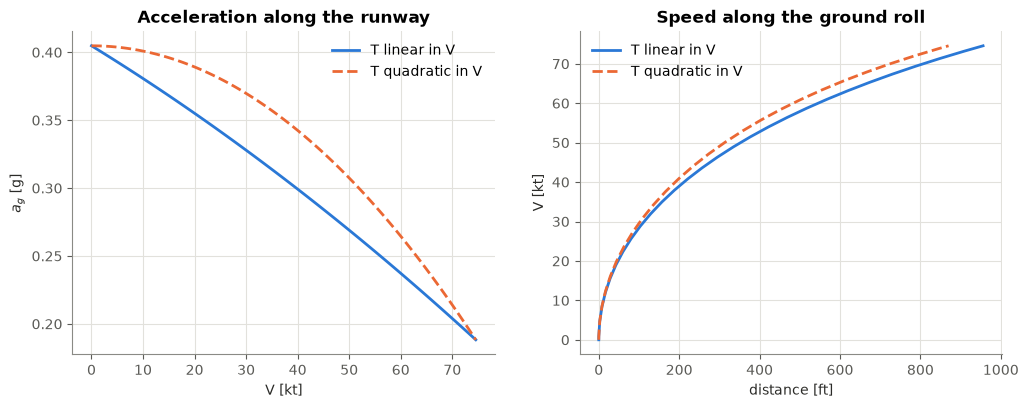

In [5]:
V_R = 1.10 * V_S
num = tl.takeoff_ground_roll_numerical(W, S, rho0, 0.89, 0.0862, 0.03, thrust_linear, V_R)

# Same inputs, but with a thrust law that makes a_g exactly linear in V^2 (Roskam's assumption)
def thrust_quadratic(V):
    return 2000 * u.LBF + (1200 - 2000) * u.LBF * (V / V_R) ** 2
num_q = tl.takeoff_ground_roll_numerical(W, S, rho0, 0.89, 0.0862, 0.03, thrust_quadratic, V_R)
app_q = tl.takeoff_roskam_approximate(**dict(ex102, thrust=thrust_quadratic))

print_table(["thrust law", "S_NGR numerical [ft]", "S_NGR Roskam k-method [ft]"],
            [["linear in V (Fig. 10.9)", num["distance"] / ft, r.S_NGR / ft],
             ["quadratic in V", num_q["distance"] / ft, app_q.S_NGR / ft]],
            ["{}", "{:.0f}", "{:.0f}"])

V = np.linspace(0, V_R, 100)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.2))
for thr, label in ((thrust_linear, "T linear in V"), (thrust_quadratic, "T quadratic in V")):
    a1.plot(V / u.KT, tl.ground_acceleration(V, W, S, rho0, thr(V), 0.89, 0.0862, 0.03) / u.G0, label=label)
a1.set_xlabel("V [kt]"); a1.set_ylabel("$a_g$ [g]"); a1.set_title("Acceleration along the runway"); a1.legend()
a2.plot(num["s"] / ft, num["V"] / u.KT, label="T linear in V")
a2.plot(num_q["s"] / ft, num_q["V"] / u.KT, label="T quadratic in V")
a2.set_xlabel("distance [ft]"); a2.set_ylabel("V [kt]"); a2.set_title("Speed along the ground roll"); a2.legend()
plt.show()

When $a_g$ is really linear in $V^2$ the $k$-method is *exact* (the two results
coincide). With the linear thrust law of Fig. 10.9 the acceleration in the
middle of the run is lower than the $V^2$-interpolation assumes, and the true
ground roll is ~10 % longer: a good example of why the assumptions behind a
closed-form result must be checked.

## 5. Take-off distance of the example aircraft

`tl.takeoff_distance(aircraft, ...)` combines the numerical ground roll (with
ground effect from the wing height) and Roskam's air-distance model. Defaults:
$V_R=1.10V_S$, $V_{LOF}=1.15V_S$, dry asphalt, 50 ft screen for propeller aircraft
and 35 ft for jets.

In [6]:
rows = []
for ac in fleet:
    r = tl.takeoff_distance(ac)
    rows.append([ac.name, r.V_LOF / u.KT, r.ground_distance, r.air_distance, r.total_distance, r.total_time])
print("Take-off at sea level, ISA, no wind, maximum take-off mass")
print_table(["aircraft", "V_LOF [kt]", "S_G [m]", "S_A [m]", "S_TO [m]", "t_TO [s]"], rows,
            ["{}", "{:.0f}", "{:.0f}", "{:.0f}", "{:.0f}", "{:.1f}"])

Take-off at sea level, ISA, no wind, maximum take-off mass
                              aircraft  V_LOF [kt]  S_G [m]  S_A [m]  S_TO [m]  t_TO [s]
--------------------------------------  ----------  -------  -------  --------  --------
Light single-engine piston (C172-like)          54      202      169       371      20.0
         Roskam light twin (C310-like)          78      234      227       462      16.6
      Regional turboprop (ATR 72-like)         120      859      370      1229      33.1
     Business jet (Gulfstream IV-like)         127      770      318      1088      26.2


Note that the Roskam twin needs 462 m here, against 532 m (1,745 ft) in
Example 10.2. The difference is the thrust model: the aircraft-level default
for propellers is $T=\min(T_{static},\,\eta_pP/V)$, which stays at the static
value (2,000 lb) up to $V_R$, whereas the measured curve of Roskam Fig. 10.9
drops to 1,200 lb at $V_R$. Real propeller data (or a `linear_thrust_model`)
can be passed with the `thrust=` argument when available:

In [7]:
print(f"Roskam twin with the thrust curve of Fig. 10.9: "
      f"{tl.takeoff_distance(twin, thrust=thrust_linear, CL_ground=0.89).total_distance:.0f} m")

Roskam twin with the thrust curve of Fig. 10.9: 553 m


### Sensitivity: weight, altitude, temperature, wind and slope

"Hot and high" airfields are the classic take-off problem: lower density
increases the lift-off *true* airspeed and reduces the thrust at the same time.

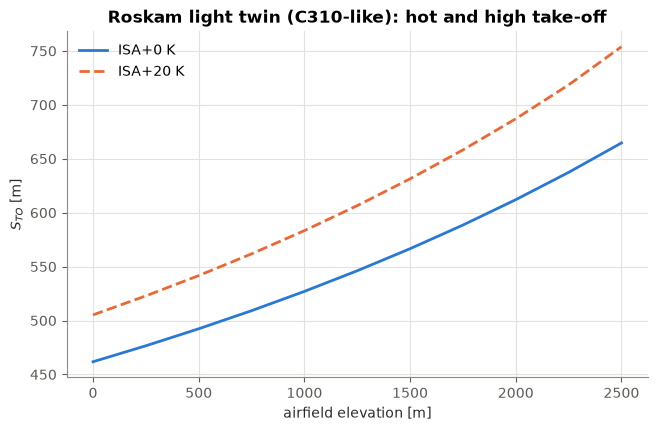

                    case  S_TO [m]  change [%]
------------------------  --------  ----------
baseline (SL, ISA, MTOM)       462        +0.0
          10 kt headwind       380       -17.8
           5 kt tailwind       504        +9.3
              2 % uphill       472        +2.3
 short grass (mu = 0.05)       473        +2.4
            90 % of MTOM       408       -11.7


In [8]:
elev = np.linspace(0, 2500, 11)
fig, ax = plt.subplots()
for dT in (0.0, 20.0):
    S_TO = [tl.takeoff_distance(twin, altitude=h, delta_T=dT).total_distance for h in elev]
    ax.plot(elev, S_TO, label=f"ISA{dT:+.0f} K")
ax.set_xlabel("airfield elevation [m]"); ax.set_ylabel("$S_{TO}$ [m]")
ax.set_title(f"{twin.name}: hot and high take-off")
ax.legend()
plt.show()

base = tl.takeoff_distance(twin).total_distance
cases = [("baseline (SL, ISA, MTOM)", {}), ("10 kt headwind", {"headwind": 10 * u.KT}),
         ("5 kt tailwind", {"headwind": -5 * u.KT}), ("2 % uphill", {"runway_slope": 0.02}),
         ("short grass (mu = 0.05)", {"mu": 0.05}), ("90 % of MTOM", {"weight": 0.9 * twin.weight})]
print_table(["case", "S_TO [m]", "change [%]"],
            [[lab, tl.takeoff_distance(twin, **kw).total_distance, 100 * (tl.takeoff_distance(twin, **kw).total_distance / base - 1)]
             for lab, kw in cases], ["{}", "{:.0f}", "{:+.1f}"])

Regulations add conservatism for wind (Roskam p. 447): only **50 % of a headwind**
may be credited, and **150 % of a tailwind** must be accounted for.

## 6. Statistical methods (Roskam Sec. 10.3.2)

For early design, Loftin's correlations relate the field length to a single
"take-off parameter":

* FAR 23, propeller: $TOP_{23} = \dfrac{(W/S)(W/P)}{\sigma\,C_{L_{max,TO}}}$ [lb²/(ft² hp)],
  $S_{TO} = 8.134\,TOP_{23} + 0.0149\,TOP_{23}^2$ ft (Eqns 10.22-10.23);
* FAR 25, jets: $TOP_{25} = \dfrac{W/S}{\sigma\,C_{L_{max,TO}}\,(T/W)}$ [lb/ft²],
  $S_{TOFL} = 37.5\,TOP_{25}$ ft (Eqns 10.24-10.25).

The functions take SI inputs and convert internally to the units of the correlations.

In [9]:
P_TO = 0.9 * 2 * 260 * u.HP     # Roskam: two 260 shp engines, 10 % installation loss
st = tl.takeoff_distance_far23_statistical(twin.wing_loading, twin.weight / P_TO, 1.0, 1.69)
print(f"Roskam twin: TOP23 = {st['TOP23']:.0f} (153), S_TO = {st['takeoff_distance']/ft:.0f} ft (1,593 ft)"
      f" vs {tl.takeoff_roskam_approximate(**ex102).total_distance/ft:.0f} ft with the analytical method")

TW = jet.propulsion.max_thrust_sl / jet.weight
st25 = tl.takeoff_field_length_far25_statistical(jet.wing_loading, TW, 1.0, jet.config("takeoff").CL_max)
print(f"Business jet: TOP25 = {st25['TOP25']:.0f} lb/ft^2, FAR 25 take-off field length = {st25['field_length']:.0f} m")

Roskam twin: TOP23 = 153 (153), S_TO = 1593 ft (1,593 ft) vs 1745 ft with the analytical method
Business jet: TOP25 = 109 lb/ft^2, FAR 25 take-off field length = 1244 m


### Balanced field length (Torenbeek, Roskam Eqn 10.57)

$$
BFL = \frac{0.863}{1+2.3\,\Delta\gamma_2}\left(\frac{W/S}{\rho g C_{L_2}} + h_{screen}\right)
\left(\frac{1}{\bar T/W-\mu'} + 2.7\right) + \frac{\Delta S_{TO}}{\sqrt\sigma}
$$

with $\Delta\gamma_2$ the excess of the OEI second-segment climb gradient over
the FAR 25.121 minimum, $\mu' = 0.01C_{L_{max,TO}}+0.02$, $C_{L_2}=0.694\,C_{L_{max,TO}}$
($V_2=1.2V_S$), $\Delta S_{TO}=655$ ft and the mean thrust $\bar T$ of Eqns
(10.58)-(10.59). The OEI gradient is computed with the climb module.

In [10]:
rows = []
for ac, dCD0 in ((jet, 0.003), (atr, 0.005)):
    conf = ac.config("takeoff")
    V2 = 1.2 * aero.stall_speed(ac.weight, ac.wing_area, rho0, conf.CL_max)
    n = ac.propulsion.n_engines
    gamma2 = climb.rate_of_climb(ac, V2, 0.0, config="takeoff", n_operative=n - 1, extra_CD0=dCD0) / V2
    if ac.is_jet:
        T_mean = tl.mean_takeoff_thrust_jet(ac.propulsion.max_thrust_sl, ac.propulsion.bypass_ratio)
    else:
        T_mean = tl.mean_takeoff_thrust_propeller(ac.propulsion.max_shaft_power_sl, 1.0, n,
                                                  ac.propulsion.propeller_diameter)
    bfl = tl.balanced_field_length_torenbeek(ac.weight, ac.wing_area, rho0, conf.CL_max, T_mean, n, gamma2)
    aeo = tl.takeoff_distance(ac, screen_height=tl.SCREEN_HEIGHT["FAR25_takeoff"]).total_distance
    rows.append([ac.name, 100 * gamma2, T_mean / ac.weight, bfl["BFL"], 1.15 * aeo])
print_table(["aircraft", "gamma2 OEI [%]", "mean T/W", "BFL Torenbeek [m]", "1.15 x AEO distance [m]"], rows,
            ["{}", "{:.2f}", "{:.3f}", "{:.0f}", "{:.0f}"])

                         aircraft  gamma2 OEI [%]  mean T/W  BFL Torenbeek [m]  1.15 x AEO distance [m]
---------------------------------  --------------  --------  -----------------  -----------------------
Business jet (Gulfstream IV-like)            5.88     0.325               1426                     1251
 Regional turboprop (ATR 72-like)            2.10     0.230               1751                     1344


/tmp/ipykernel_4730/4064068393.py:12: PerformanceWarning: The OEI second-segment gradient 0.0210 is below the FAR 25.121 minimum 0.024: the aircraft is not certifiable at this weight.
  bfl = tl.balanced_field_length_torenbeek(ac.weight, ac.wing_area, rho0, conf.CL_max, T_mean, n, gamma2)


The turboprop's second-segment gradient is below the 2.4 % minimum (see
notebook 03): the function warns that the aircraft would not be certifiable at
this weight - it does not silently return a number as if nothing happened.
FAR 25.113 takes the larger of the OEI accelerate-go distance and 1.15 times
the all-engines distance; the BFL is usually the governing one for twins.

## 7. Landing (Roskam Secs. 10.4-10.6)

$$
S_L = \underbrace{S_{LA}}_{\text{approach + flare}} + \underbrace{S_{LR}}_{\text{free roll}} + \underbrace{S_{LNGR}}_{\text{braking}}
$$

* approach at $V_A = 1.3V_{S}$ on a glide path $\bar\gamma_A = C_D/C_L - T/W$ (Eqn 10.81),
  from the 50 ft screen;
* circular flare of radius $R = V_{FL}^2/(g(n_{FL}-1))$, $V_{FL}=0.95V_A$, $n_{FL}\approx1.04$-$1.08$ (Eqn 10.107);
  $S_{LA} = h_{screen}/\bar\gamma_A + R\,\bar\gamma_A/2$ (Eqn 10.106);
* touchdown at $V_{TD}\approx1.15V_S$, free roll for $t_{FR}$ (1-3 s): $S_{LR}=V_{TD}\,t_{FR}$;
* braked roll with $\mu_{brake}$ on the main gear (a fraction $N_n/W\approx0.08$ of the
  weight on the unbraked nose wheel), closed form (Eqns 10.112-10.115):
  $S_{LNGR} = \frac{1}{B}\ln\left(1+\frac{B}{A}V_{TD}^2\right)$.

The FAR 25 **landing field length** is $S_L/0.6$ (Eqn 10.103).

Roskam Example 10.3 (same twin, landing flaps 45°, $C_{L_{max}}=2.12$,
$C_D = 0.10 + C_L^2/(\pi A e)$, $T = 260$ lb in the approach and on the ground,
$\mu_{brake}=0.4$, $C_{L_g}=0.40$, $C_{D_g}=0.30$):

In [11]:
polar_L = ParabolicDragPolar.from_aspect_ratio(0.100, 7.0, 0.80)
L = tl.landing_roskam_approximate(W, S, rho0, 2.12, polar_L, mu_brake=0.40, CL_ground=0.40, CD_ground=0.30,
                                  approach_thrust=260 * u.LBF, ground_thrust=260 * u.LBF, n_flare=1.08,
                                  t_free_roll=1.0)
print_table(["quantity", "this code", "Roskam Table 10.4"],
            [["V_S [ft/s]", L.V_S / ft, 102.1], ["V_A [ft/s]", L.V_A / ft, 132.7],
             ["approach angle [deg]", np.degrees(L.gamma_A), 5.4], ["flare radius [ft]", L.R_flare / ft, 6173],
             ["S_LA [ft]", L.S_LA / ft, 821], ["S_LR [ft]", L.S_LR / ft, 117], ["S_LNGR [ft]", L.S_LNGR / ft, 601],
             ["S_L [ft]", L.total_distance / ft, 1539], ["FAR 25 field length [ft]", L.far25_field_length / ft, 2565]],
            ["{}", "{:.1f}", "{:.1f}"])
stat = tl.landing_distance_far23_statistical(L.V_S)
print(f"\nFAR 23 statistical method: S_LG = {stat['ground_roll']/ft:.0f} ft (968), "
      f"S_L = {stat['landing_distance']/ft:.0f} ft (1,876)")

                quantity  this code  Roskam Table 10.4
------------------------  ---------  -----------------
              V_S [ft/s]      102.1              102.1
              V_A [ft/s]      132.8              132.7
    approach angle [deg]        5.4                5.4
       flare radius [ft]     6182.2             6173.0
               S_LA [ft]      819.9              821.0
               S_LR [ft]      117.5              117.0
             S_LNGR [ft]      603.4              601.0
                S_L [ft]     1540.7             1539.0
FAR 25 field length [ft]     2567.8             2565.0

FAR 23 statistical method: S_LG = 971 ft (968), S_L = 1881 ft (1,876)


The statistical estimate is 22 % higher than the analytical one, as noted by
Roskam: the correlations include the scatter of real pilot technique.

### Numerical landing roll and sensitivity

`tl.landing_distance(aircraft, ...)` uses Roskam's air distance (3° approach by
default) and integrates the ground roll numerically, including wind, slope, the
free-roll phase and the nose-wheel load.

Landing at sea level, ISA, 90 % MTOM, dry runway (mu_brake = 0.4), 3 deg approach
                              aircraft  V_A [kt]  air [m]  ground [m]  S_L [m]  S_L / 0.6 [m]
--------------------------------------  --------  -------  ----------  -------  -------------
Light single-engine piston (C172-like)        55      315         121      436            726
         Roskam light twin (C310-like)        75      335         206      541            902
      Regional turboprop (ATR 72-like)       116      398         500      898           1497
     Business jet (Gulfstream IV-like)       120      406         628     1034           1723


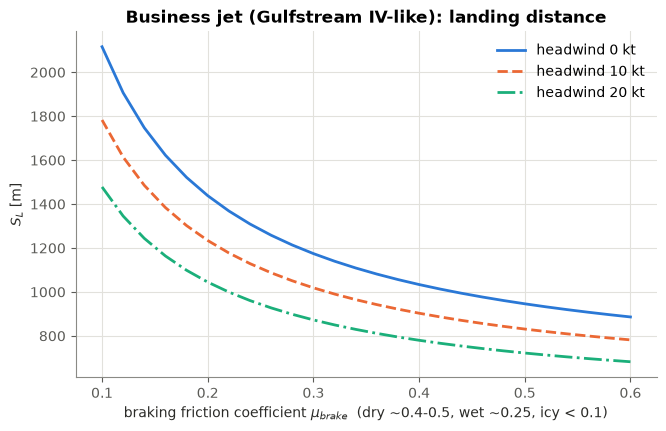

In [12]:
rows = []
for ac in fleet:
    Ld = tl.landing_distance(ac, weight=0.9 * ac.weight)
    rows.append([ac.name, Ld.V_A / u.KT, Ld.S_LA, Ld.ground_distance, Ld.total_distance, Ld.far25_field_length])
print("Landing at sea level, ISA, 90 % MTOM, dry runway (mu_brake = 0.4), 3 deg approach")
print_table(["aircraft", "V_A [kt]", "air [m]", "ground [m]", "S_L [m]", "S_L / 0.6 [m]"], rows,
            ["{}", "{:.0f}", "{:.0f}", "{:.0f}", "{:.0f}", "{:.0f}"])

mus = np.linspace(0.1, 0.6, 26)
fig, ax = plt.subplots()
for hw_kt in (0, 10, 20):
    ax.plot(mus, [tl.landing_distance(jet, weight=0.9 * jet.weight, mu_brake=m, headwind=hw_kt * u.KT).total_distance
                  for m in mus], label=f"headwind {hw_kt} kt")
ax.set_xlabel("braking friction coefficient $\\mu_{brake}$  (dry ~0.4-0.5, wet ~0.25, icy < 0.1)"); ax.set_ylabel("$S_L$ [m]")
ax.set_title(f"{jet.name}: landing distance")
ax.legend()
plt.show()

## 8. Exercises

1. Roskam Problem 10.1: find the thrust needed by a 56,000 lb jet
   ($S=900$ ft$^2$, $C_D=0.016+0.04C_L^2$ in ground effect, $\mu=0.02$,
   $C_{L_{max,TO}}=1.8$, $C_{L_g}=1.0$, $V_{LOF}=1.2V_S$) to lift off in 3,000 ft
   (hint: bisection on a constant thrust with `takeoff_ground_roll_numerical`).
2. Compute the take-off distance of the light single from a 1,500 m high
   airfield on an ISA+25 day on short grass.
3. Model reverse thrust on the jet landing (`ground_thrust=lambda V: -0.3 * T_max`
   in `landing_ground_roll_numerical`) and quantify the saving on a wet runway.